# 1. Set Up Notebook and Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import datetime
from plotly.graph_objects import Sankey
from sklearn.preprocessing import MinMaxScaler
from plotly.subplots import make_subplots

# 2. Load and Inspect the Dataset


In [2]:
def load_raw_data(path):
    """Load CSV, print shape and dtype summary."""
    df = pd.read_csv(path)
    print(f"Loaded → shape {df.shape}")
    print(df.dtypes.value_counts().to_string())
    print(df.head(3).to_string())
    return df

df = load_raw_data("/Users/adnanansari/Desktop/Data/Agrofood_co2_emission.csv")
print(df.shape)

Loaded → shape (6965, 31)
float64    29
object      1
int64       1
          Area  Year  Savanna fires  Forest fires  Crop Residues  Rice Cultivation  Drained organic soils (CO2)  Pesticides Manufacturing  Food Transport  Forestland  Net Forest conversion  Food Household Consumption  Food Retail  On-farm Electricity Use  Food Packaging  Agrifood Systems Waste Disposal  Food Processing  Fertilizers Manufacturing      IPPU  Manure applied to Soils  Manure left on Pasture  Manure Management  Fires in organic soils  Fires in humid tropical forests  On-farm energy use  Rural population  Urban population  Total Population - Male  Total Population - Female  total_emission  Average Temperature °C
0  Afghanistan  1990        14.7237        0.0557       205.6077            686.00                          0.0                 11.807483         63.1152   -2388.803                    0.0                     79.0851     109.6446                  14.2666       67.631366                         691.78

In [3]:
print(df.head())

          Area  Year  Savanna fires  Forest fires  Crop Residues  \
0  Afghanistan  1990        14.7237        0.0557       205.6077   
1  Afghanistan  1991        14.7237        0.0557       209.4971   
2  Afghanistan  1992        14.7237        0.0557       196.5341   
3  Afghanistan  1993        14.7237        0.0557       230.8175   
4  Afghanistan  1994        14.7237        0.0557       242.0494   

   Rice Cultivation  Drained organic soils (CO2)  Pesticides Manufacturing  \
0            686.00                          0.0                 11.807483   
1            678.16                          0.0                 11.712073   
2            686.00                          0.0                 11.712073   
3            686.00                          0.0                 11.712073   
4            705.60                          0.0                 11.712073   

   Food Transport  Forestland  ...  Manure Management  Fires in organic soils  \
0         63.1152   -2388.803  ...       

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965 entries, 0 to 6964
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             6965 non-null   object 
 1   Year                             6965 non-null   int64  
 2   Savanna fires                    6934 non-null   float64
 3   Forest fires                     6872 non-null   float64
 4   Crop Residues                    5576 non-null   float64
 5   Rice Cultivation                 6965 non-null   float64
 6   Drained organic soils (CO2)      6965 non-null   float64
 7   Pesticides Manufacturing         6965 non-null   float64
 8   Food Transport                   6965 non-null   float64
 9   Forestland                       6472 non-null   float64
 10  Net Forest conversion            6472 non-null   float64
 11  Food Household Consumption       6492 non-null   float64
 12  Food Retail         

In [5]:
print(df.isna().sum().sort_values(ascending=False))

Crop Residues                      1389
On-farm energy use                  956
Manure applied to Soils             928
Manure Management                   928
IPPU                                743
Net Forest conversion               493
Forestland                          493
Food Household Consumption          473
Fires in humid tropical forests     155
Forest fires                         93
Savanna fires                        31
Total Population - Male               0
Urban population                      0
Total Population - Female             0
total_emission                        0
Rural population                      0
Fires in organic soils                0
Manure left on Pasture                0
Area                                  0
Agrifood Systems Waste Disposal       0
Fertilizers Manufacturing             0
Food Processing                       0
Year                                  0
Food Packaging                        0
On-farm Electricity Use               0


# 3. Cleaning the Dataset

In [6]:
continent_mapping = {
    'Africa': ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde',
               'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', "Côte d'Ivoire",
               'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon',
               'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya',
               'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique',
               'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'São Tomé and Príncipe', 'Senegal',
               'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan',
               'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'],
    'Asia': ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei',
             'Cambodia', 'China', 'Cyprus', 'Georgia', 'India', 'Indonesia', 'Iran', 'Iraq',
             'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon',
             'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman',
             'Pakistan', 'Palestine', 'Philippines', 'Qatar', 'Russia', 'Saudi Arabia', 'Singapore',
             'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand', 'Timor-Leste',
             'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'],
    'Europe': ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina',
               'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France',
               'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia',
               'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco',
               'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal',
               'Romania', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
               'Switzerland', 'Ukraine', 'United Kingdom', 'Vatican City'],
    'North America': ['Antigua and Barbuda', 'Bahamas', 'Barbados', 'Belize', 'Canada', 'Costa Rica',
                      'Cuba', 'Dominica', 'Dominican Republic', 'El Salvador', 'Grenada', 'Guatemala',
                      'Haiti', 'Honduras', 'Jamaica', 'Mexico', 'Nicaragua', 'Panama',
                      'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines',
                      'Trinidad and Tobago', 'United States'],
    'South America': ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana',
                      'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela'],
    'Oceania': ['Australia', 'Fiji', 'Kiribati', 'Marshall Islands', 'Micronesia', 'Nauru',
                'New Zealand', 'Palau', 'Papua New Guinea', 'Samoa', 'Solomon Islands', 'Tonga',
                'Tuvalu', 'Vanuatu']
}

country_to_continent = {
    country: continent
    for continent, countries in continent_mapping.items()
    for country in countries
}

In [7]:
def clean_data(df):
    """
    Clean the raw DataFrame.
    Steps: strip whitespace, remove duplicates,
    impute missing values (country median then global median),
    map countries to continents.
    """
    out = df.copy()

    # 1. Standardize column names and country names
    out.columns = out.columns.str.strip()
    out["Area"] = out["Area"].str.strip()

    # 2. Check and remove duplicates
    n_dupes = out.duplicated().sum()
    print(f"Duplicates found: {n_dupes}")
    out = out.drop_duplicates()

    # 3. Missing values BEFORE cleaning
    missing_before = out.isnull().sum().sort_values(ascending=False)
    print("\nMissing values BEFORE cleaning:")
    print(missing_before[missing_before > 0])

    # 4. Handle missing numeric values (country median → global median)
    num_cols = [c for c in out.select_dtypes(include=np.number).columns if c != "Year"]
    out[num_cols] = out.groupby("Area")[num_cols].transform(
        lambda x: x.fillna(x.median())
    )
    out[num_cols] = out[num_cols].fillna(out[num_cols].median())

    # 5. Continent mapping
    out["continent"] = out["Area"].map(country_to_continent).fillna("Other")

    # 6. Missing values AFTER cleaning
    missing_after = out.isnull().sum().sort_values(ascending=False)
    print("\nMissing values AFTER cleaning:")
    print(missing_after[missing_after > 0])

    # 7. Final checks
    print("\nData shape:", out.shape)
    print("\nColumns:")
    print(out.columns.tolist())
    print("\nSample data:")
    print(out.head())
    return out
    

In [8]:
df_clean = clean_data(df)

Duplicates found: 0

Missing values BEFORE cleaning:
Crop Residues                      1389
On-farm energy use                  956
Manure applied to Soils             928
Manure Management                   928
IPPU                                743
Net Forest conversion               493
Forestland                          493
Food Household Consumption          473
Fires in humid tropical forests     155
Forest fires                         93
Savanna fires                        31
dtype: int64

Missing values AFTER cleaning:
Series([], dtype: int64)

Data shape: (6965, 32)

Columns:
['Area', 'Year', 'Savanna fires', 'Forest fires', 'Crop Residues', 'Rice Cultivation', 'Drained organic soils (CO2)', 'Pesticides Manufacturing', 'Food Transport', 'Forestland', 'Net Forest conversion', 'Food Household Consumption', 'Food Retail', 'On-farm Electricity Use', 'Food Packaging', 'Agrifood Systems Waste Disposal', 'Food Processing', 'Fertilizers Manufacturing', 'IPPU', 'Manure applied to 

# 4. Feature Engineering

In [9]:
def engineer_features(df):
    """
    Derive analytical features from the cleaned dataset.
    New columns: pop_tot, emission_per_capita, urban_ratio,
    emission_change, temp_change, emission_pct_change,
    emission_3yr_avg, emission_zscore, high_emitter_flag,
    dominant_source, year_dt, decade.
    """
    out = df.copy().sort_values(["Area", "Year"])

    # Total population
    out["pop_tot"] = (
        out["Total Population - Male"] + out["Total Population - Female"]
    )

    # Emission per capita
    out["emission_per_capita"] = out["total_emission"] / out["pop_tot"]
    out["emission_per_capita"] = out["emission_per_capita"].replace([np.inf, -np.inf], np.nan)
    out["emission_per_capita"] = out["emission_per_capita"].fillna(out["emission_per_capita"].median())

    # Urban ratio
    out["urban_ratio"] = out["Urban population"] / (
        out["Urban population"] + out["Rural population"]
    )
    out["urban_ratio"] = out["urban_ratio"].replace([np.inf, -np.inf], np.nan)
    out["urban_ratio"] = out["urban_ratio"].fillna(out["urban_ratio"].median())

    # Year-over-year change features
    grp = out.groupby("Area")
    out["emission_change"]     = grp["total_emission"].diff().fillna(0)
    out["temp_change"]         = grp["Average Temperature °C"].diff().fillna(0)
    out["emission_pct_change"] = grp["total_emission"].pct_change().fillna(0) * 100

    # Rolling 3-year average
    out["emission_3yr_avg"] = grp["total_emission"].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )

    # Z-score within each continent × year
    def _zscore(x):
        std = x.std()
        return (x - x.mean()) / std if std > 0 else pd.Series(0, index=x.index)

    out["emission_zscore"] = (
        out.groupby(["continent", "Year"])["total_emission"].transform(_zscore)
    )

    # Binary flag: above 75th percentile of emission per capita
    p75 = out["emission_per_capita"].quantile(0.75)
    out["high_emitter_flag"] = (out["emission_per_capita"] > p75).astype(int)

    # Dominant emission source
    emission_cols = [
        "Savanna fires", "Forest fires", "Crop Residues", "Rice Cultivation",
        "Drained organic soils (CO2)", "Pesticides Manufacturing", "Food Transport",
        "Forestland", "Net Forest conversion", "Food Household Consumption",
        "Food Retail", "On-farm Electricity Use", "Food Packaging",
        "Agrifood Systems Waste Disposal", "Food Processing",
        "Fertilizers Manufacturing", "IPPU", "Manure applied to Soils",
        "Manure left on Pasture", "Manure Management",
        "Fires in organic soils", "Fires in humid tropical forests",
        "On-farm energy use"
    ]
    out["dominant_source"] = out[emission_cols].idxmax(axis=1)

    # Datetime handling
    out["year_dt"] = pd.to_datetime(out["Year"].astype(int), format="%Y")
    out["decade"]  = (out["Year"] // 10 * 10).astype(str) + "s"

    print(f"Features engineered: {out.shape[1]} total columns")
    print(out.columns.tolist())
    return out, emission_cols

In [10]:
df_clean, emission_cols = engineer_features(df_clean)

print(df_clean.columns.tolist())
df_clean.head()

Features engineered: 44 total columns
['Area', 'Year', 'Savanna fires', 'Forest fires', 'Crop Residues', 'Rice Cultivation', 'Drained organic soils (CO2)', 'Pesticides Manufacturing', 'Food Transport', 'Forestland', 'Net Forest conversion', 'Food Household Consumption', 'Food Retail', 'On-farm Electricity Use', 'Food Packaging', 'Agrifood Systems Waste Disposal', 'Food Processing', 'Fertilizers Manufacturing', 'IPPU', 'Manure applied to Soils', 'Manure left on Pasture', 'Manure Management', 'Fires in organic soils', 'Fires in humid tropical forests', 'On-farm energy use', 'Rural population', 'Urban population', 'Total Population - Male', 'Total Population - Female', 'total_emission', 'Average Temperature °C', 'continent', 'pop_tot', 'emission_per_capita', 'urban_ratio', 'emission_change', 'temp_change', 'emission_pct_change', 'emission_3yr_avg', 'emission_zscore', 'high_emitter_flag', 'dominant_source', 'year_dt', 'decade']
['Area', 'Year', 'Savanna fires', 'Forest fires', 'Crop Residu

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,...,urban_ratio,emission_change,temp_change,emission_pct_change,emission_3yr_avg,emission_zscore,high_emitter_flag,dominant_source,year_dt,decade
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,...,0.211766,0.00000,0.000000,0.000000,2198.963539,-0.443371,0,Manure left on Pasture,1990-01-01,1990s
1,Afghanistan,1991,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,...,0.212655,124.91309,-0.515500,5.680544,2261.420084,-0.442266,0,Manure left on Pasture,1991-01-01,1990s
2,Afghanistan,1992,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,...,0.213548,32.42760,-0.280250,1.395410,2293.048132,-0.400598,0,Manure left on Pasture,1992-01-01,1990s
3,Afghanistan,1993,14.7237,0.0557,230.8175,686.00,0.0,11.712073,54.3617,-2388.803,...,0.214441,12.16630,0.361500,0.516330,2349.550462,-0.399323,0,Manure left on Pasture,1993-01-01,1990s
4,Afghanistan,1994,14.7237,0.0557,242.0494,705.60,0.0,11.712073,53.9874,-2388.803,...,0.215338,132.29820,0.270333,5.585807,2408.514496,-0.394779,0,Manure left on Pasture,1994-01-01,1990s


In [11]:
def document_assumptions(df):
    """
    Print a structured log of data engineering
    assumptions, statistics and limitations.
    """
    print(f"Assumption log | {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    print("\n[1] Imputation: median chosen — emission cols are right-skewed:")
    print(df[emission_cols].skew().nlargest(3).to_string())

    print(f"\n[2] Year range  : {df['Year'].min()} – {df['Year'].max()}")
    print(f"    year_dt type: {df['year_dt'].dtype}")
    print(f"    min={df['year_dt'].min().date()}, max={df['year_dt'].max().date()}")

    print(f"\n[3] Continent 'Other' rows: {(df['continent']=='Other').sum()} "
          f"(retained for global totals, excluded from continent plots)")

    print(f"\n[4] high_emitter_flag: {df['high_emitter_flag'].mean()*100:.1f}% flagged (expected ~25%)")
    print(f"    urban_ratio range : {df['urban_ratio'].min():.3f} – {df['urban_ratio'].max():.3f}")

    print("\n[5] Limitations:")
    print("    • USSR rows mapped to Russia — pre-1991 data aggregated at union level")
    print("    • China, mainland excludes HK/Taiwan — noted in per-capita calculations")
    print("    • Median imputation may underestimate variance for sparse countries")

document_assumptions(df_clean)

Assumption log | 2026-03-28 14:48:15

[1] Imputation: median chosen — emission cols are right-skewed:
Fires in organic soils    26.357767
Net Forest conversion     12.210396
Food Packaging            11.979253

[2] Year range  : 1990 – 2020
    year_dt type: datetime64[ns]
    min=1990-01-01, max=2020-01-01

[3] Continent 'Other' rows: 1743 (retained for global totals, excluded from continent plots)

[4] high_emitter_flag: 25.0% flagged (expected ~25%)
    urban_ratio range : 0.000 – 1.000

[5] Limitations:
    • USSR rows mapped to Russia — pre-1991 data aggregated at union level
    • China, mainland excludes HK/Taiwan — noted in per-capita calculations
    • Median imputation may underestimate variance for sparse countries


# 5. Reshape and Aggregate the Data

Convert wide emission columns into long format for source-level analysis.

In [12]:
def reshape_data(df):
    """
    Reshape wide emission columns into long format
    for source-level analysis and visualisation.
    """
    long = df.melt(
        id_vars=[
            "Area", "Year", "total_emission",
            "Average Temperature °C", "pop_tot",
            "continent", "emission_per_capita"
        ],
        value_vars=emission_cols,
        var_name="emission_source",
        value_name="emission_value"
    )
    print(f"Long format shape: {long.shape}")
    return long

In [13]:
long_df = reshape_data(df_clean)

Long format shape: (160195, 9)


In [14]:
def aggregate_data(df, long):
    """
    Produce all aggregated views required for visualisation.
    Returns a dictionary of DataFrames.
    """
    agg_core = {
        "total_emission": "mean",
        "Average Temperature °C": "mean",
        "emission_per_capita": "mean",
        "pop_tot": "mean",
        "urban_ratio": "mean"
    }

    # 1. Yearly overall trend
    yearly = df.groupby("Year", as_index=False).agg(agg_core)

    # 2. Country-wise summary
    country_summary = df.groupby("Area", as_index=False).agg(agg_core)

    # 3. Continent-wise summary
    continent_summary = df.groupby("continent", as_index=False).agg(agg_core)

    # 4. Emission source by year
    source_year = long.groupby(
        ["Year", "emission_source"], as_index=False
    )["emission_value"].sum()

    # 5. Emission source by continent
    source_continent = long.groupby(
        ["continent", "emission_source"], as_index=False
    )["emission_value"].sum()

    # 6. Country + Year level summary
    country_year = df.groupby(["Area", "Year"], as_index=False).agg(agg_core)

    # 7. Continent + Year level summary
    continent_year = df.groupby(["continent", "Year"], as_index=False).agg({
        **agg_core, "total_emission": "sum", "pop_tot": "sum"
    })

    # 8. Pivot table
    pivot_sources = long.pivot_table(
        index="Year",
        columns="emission_source",
        values="emission_value",
        aggfunc="sum"
    ).fillna(0).reset_index()

    for name, frame in zip(
        ["yearly", "country_summary", "continent_summary", "source_year",
         "source_continent", "country_year", "continent_year", "pivot_sources"],
        [yearly, country_summary, continent_summary, source_year,
         source_continent, country_year, continent_year, pivot_sources]
    ):
        print(f"{name:25s} → {frame.shape}")

    return (yearly, country_summary, continent_summary, source_year,
            source_continent, country_year, continent_year, pivot_sources)

In [15]:
(yearly, country_summary, continent_summary, source_year,
 source_continent, country_year, continent_year, pivot_sources) = aggregate_data(df_clean, long_df)

yearly                    → (31, 6)
country_summary           → (236, 6)
continent_summary         → (7, 6)
source_year               → (713, 3)
source_continent          → (161, 3)
country_year              → (6965, 7)
continent_year            → (217, 7)
pivot_sources             → (31, 24)


# 6. Exploratory Data Analysis (EDA)

### 6A. Line Graphs — Long-Term Trends

In [16]:
def normalizer(data):
    return (data - data.min()) / (data.max() - data.min())

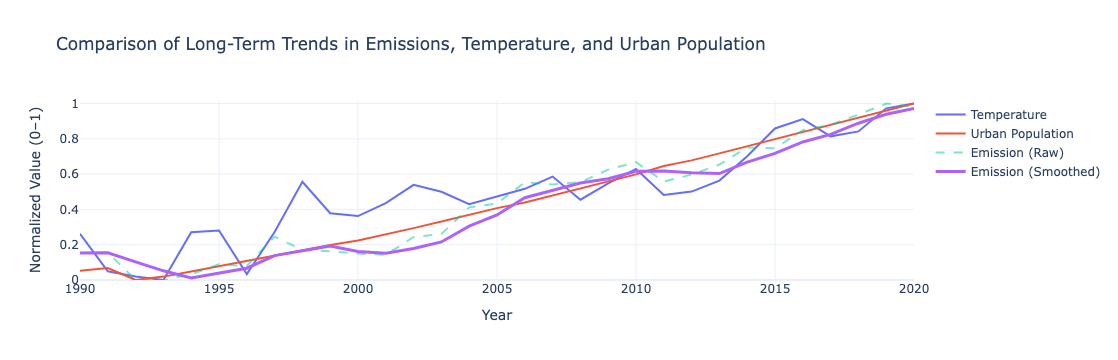

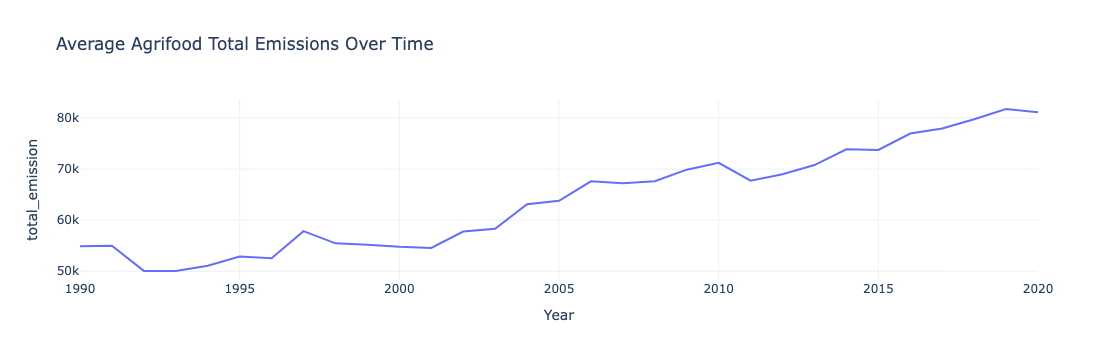

In [17]:


# 1. Aggregate yearly data
yearly = df_clean.groupby("Year").agg({
    "Average Temperature °C": "mean",
    "total_emission": "mean",
    "Urban population": "mean"
}).reset_index()

# 2. Normalize data (0–1 scale)
scaler = MinMaxScaler()
cols = ["Average Temperature °C", "total_emission", "Urban population"]

yearly_norm = yearly.copy()
yearly_norm[cols] = scaler.fit_transform(yearly[cols])

# 3. Smooth emissions (rolling average)
yearly_norm["Emission Smoothed"] = yearly_norm["total_emission"].rolling(
    window=3, min_periods=1
).mean()

# ===== 4. INTERACTIVE MULTI-LINE CHART =====
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=yearly_norm["Year"],
    y=yearly_norm["Average Temperature °C"],
    mode='lines',
    name='Temperature'
))

fig.add_trace(go.Scatter(
    x=yearly_norm["Year"],
    y=yearly_norm["Urban population"],
    mode='lines',
    name='Urban Population'
))

fig.add_trace(go.Scatter(
    x=yearly_norm["Year"],
    y=yearly_norm["total_emission"],
    mode='lines',
    name='Emission (Raw)',
    line=dict(dash='dash'),
    opacity=0.5
))

fig.add_trace(go.Scatter(
    x=yearly_norm["Year"],
    y=yearly_norm["Emission Smoothed"],
    mode='lines',
    name='Emission (Smoothed)',
    line=dict(width=3)
))

fig.update_layout(
    title="Comparison of Long-Term Trends in Emissions, Temperature, and Urban Population",
    xaxis_title="Year",
    yaxis_title="Normalized Value (0–1)",
    xaxis=dict(range=[1990, 2020], dtick=5),
    yaxis=dict(range=[0, 1.02]),
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

# ===== 5. INTERACTIVE EMISSION TREND =====
fig2 = px.line(
    yearly,
    x="Year",
    y="total_emission",
    title="Average Agrifood Total Emissions Over Time"
)

fig2.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

fig2.show()

###  Insight: Long-Term Co-Movement of Emissions, Temperature, and Urban Population

- Emissions, temperature, and urban population all exhibit a clear upward trend over time, indicating strong long-term alignment between human activity and environmental impact.
- The steady increase in urban population closely mirrors the smoothed emission trend, suggesting that urbanization is a key structural driver of rising emissions.
- While temperature shows greater short-term variability, its overall upward trajectory follows the same pattern, supporting the idea that sustained emission growth contributes to long-term climate change.
- This co-movement highlights the systemic link between urban expansion, agricultural production, and environmental pressure.

###  Insight: Persistent Growth in Agrifood Emissions

- Average agrifood emissions show a strong and consistent upward trend across the entire period.
- A noticeable acceleration occurs after the early 2000s, suggesting a structural shift in agricultural intensity.
- The long-term trajectory remains strongly positive, implying that emission growth is persistent and not cyclical.

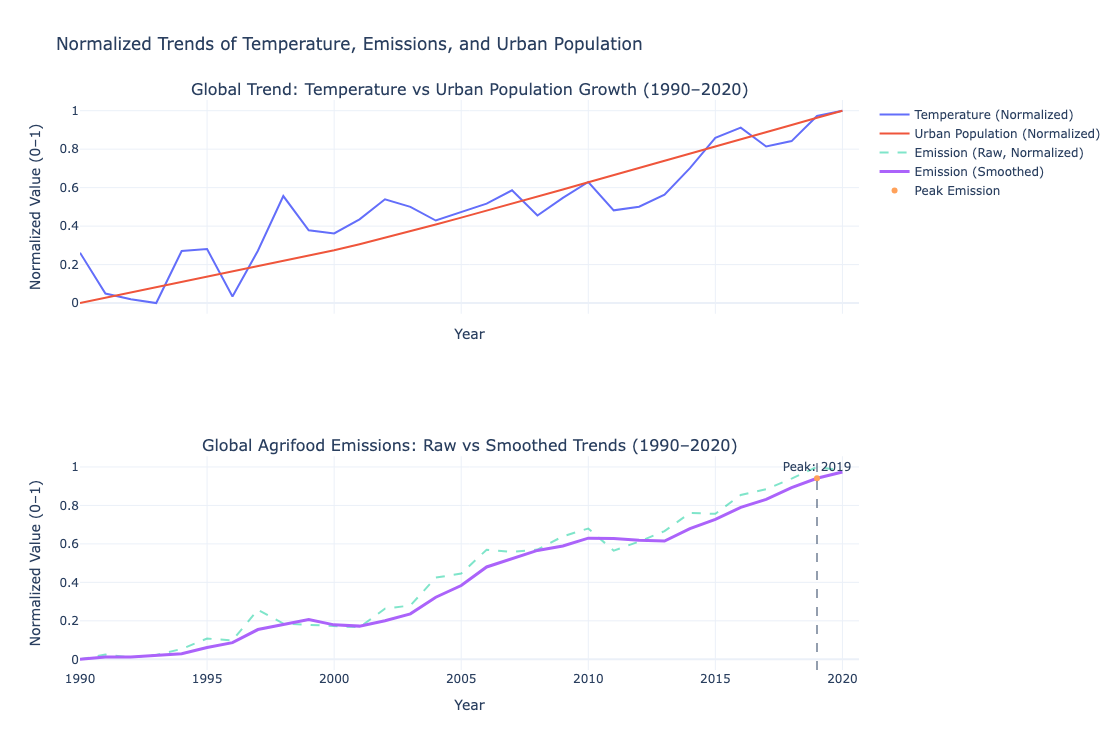

In [18]:
# ===== 1. Aggregate yearly data =====
yearly = df_clean.groupby("Year", as_index=False).agg({
    "Average Temperature °C": "mean",
    "total_emission": "sum",
    "Urban population": "sum"
})

# ===== 2. Normalize =====
scaler = MinMaxScaler()
cols = ["Average Temperature °C", "total_emission", "Urban population"]

yearly_norm = yearly.copy()
yearly_norm[cols] = scaler.fit_transform(yearly[cols])

# ===== 3. Smooth emissions =====
yearly_norm["Emission Smoothed"] = yearly_norm["total_emission"].rolling(
    window=3, min_periods=1
).mean()

# ===== 4. Peak emission year =====
peak_idx   = yearly["total_emission"].idxmax()
peak_year  = yearly.loc[peak_idx, "Year"]
peak_value = yearly_norm.loc[peak_idx, "Emission Smoothed"]

# ===== 5. Create Subplots =====
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=[
        "Global Trend: Temperature vs Urban Population Growth (1990–2020)",
        "Global Agrifood Emissions: Raw vs Smoothed Trends (1990–2020)"
    ]
)

# ===== Panel 1: Temperature + Urban Population =====
fig.add_trace(go.Scatter(
    x=yearly_norm["Year"],
    y=yearly_norm["Average Temperature °C"],
    mode='lines',
    name='Temperature (Normalized)'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=yearly_norm["Year"],
    y=yearly_norm["Urban population"],
    mode='lines',
    name='Urban Population (Normalized)'
), row=1, col=1)

# ===== Panel 2: Emissions =====
fig.add_trace(go.Scatter(
    x=yearly_norm["Year"],
    y=yearly_norm["total_emission"],
    mode='lines',
    name='Emission (Raw, Normalized)',
    line=dict(dash='dash'),
    opacity=0.5
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=yearly_norm["Year"],
    y=yearly_norm["Emission Smoothed"],
    mode='lines',
    name='Emission (Smoothed)',
    line=dict(width=3)
), row=2, col=1)

# ===== Peak marker =====
fig.add_trace(go.Scatter(
    x=[peak_year],
    y=[peak_value],
    mode='markers+text',
    text=[f"Peak: {peak_year}"],
    textposition="top center",
    name='Peak Emission'
), row=2, col=1)

# Vertical line for peak year
fig.add_vline(
    x=peak_year,
    line_dash="dash",
    opacity=0.5,
    row=2, col=1
)

# ===== Layout =====
fig.update_layout(
    title="Normalized Trends of Temperature, Emissions, and Urban Population",
    template="plotly_white",
    hovermode="x unified",
    height=750
)

# Axis labels
fig.update_yaxes(title_text="Normalized Value (0–1)", row=1, col=1)
fig.update_yaxes(title_text="Normalized Value (0–1)", row=2, col=1)
fig.update_xaxes(title_text="Year", dtick=5)

fig.show()

###  Insight: Urban Growth and Gradual Climate Response

- Urban population increases steadily and predictably over time.
- Temperature shows more volatility but maintains a clear upward trend, indicating a gradual response to long-term environmental changes.
- This pattern supports the idea of an indirect relationship, where urban expansion drives emissions, which in turn contribute to long-term temperature increases.

### Insight: Rising Emissions with Reduced Volatility Over Time

- Raw emissions display noticeable short-term fluctuations, but the smoothed trend reveals a clear and sustained increase.
- The peak around 2019 represents the highest emission level in the dataset, highlighting recent intensification of environmental pressure.

### 6B. Bubble Scatter — CO₂ Emission vs Temperature by Country

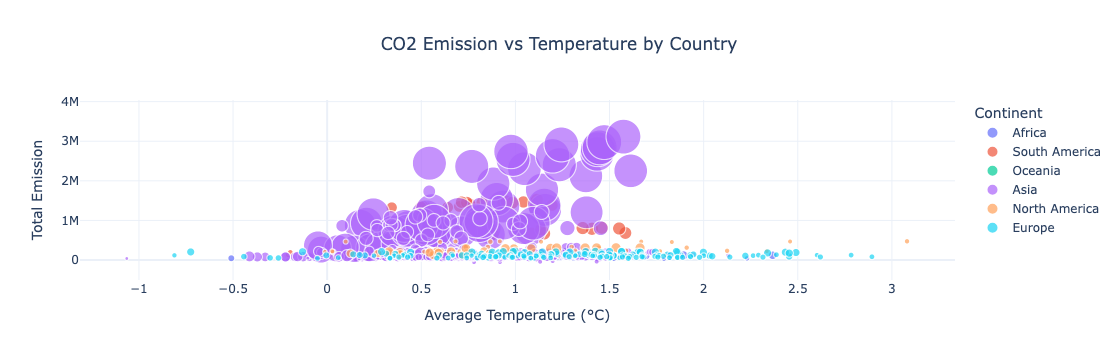

In [19]:
plot_df = df_clean.copy()
plot_df = plot_df[plot_df["continent"] != "Other"]
plot_df = plot_df.dropna(subset=["Average Temperature °C", "total_emission", "pop_tot", "continent"])
plot_df = plot_df[plot_df["pop_tot"] > 0]

top_countries = (
    plot_df.groupby("Area")["total_emission"]
    .mean()
    .nlargest(40)
    .index
)
plot_df = plot_df[plot_df["Area"].isin(top_countries)]

fig = px.scatter(
    plot_df,
    x="Average Temperature °C",
    y="total_emission",
    size="pop_tot",
    color="continent",
    hover_name="Area",
    hover_data={
        "Year": True,
        "pop_tot": ":,.0f",
        "Average Temperature °C": ":.2f",
        "total_emission": ":,.2f",
        "continent": True
    },
    title="CO2 Emission vs Temperature by Country",
    template="plotly_white",  
    size_max=35,
    opacity=0.7
)

# Optional: force pure white background
fig.update_layout(
    xaxis_title="Average Temperature (°C)",
    yaxis_title="Total Emission",
    legend_title="Continent",
    title_x=0.5,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

###  Insight: Uneven Global Distribution of Emissions and Temperature Impact

- There is a clear positive relationship between temperature and emissions, but the distribution is highly uneven across continents.
- Asia dominates the upper emission range, while Africa and Oceania remain clustered at lower emission levels despite varying temperature ranges.
- Similar temperature levels can correspond to vastly different emission outputs, highlighting that emissions are driven more by economic and production scale than climate alone.

### 6C. Temperature vs CO₂ Emissions — Global Relationship Over Time

In [20]:
correlation = df_clean.groupby("Year", as_index=False).agg({
    "total_emission": "sum",
    "Average Temperature °C": "mean",
    "pop_tot": "sum"
})
print(correlation.corr())

                            Year  total_emission  Average Temperature °C  \
Year                    1.000000        0.982116                0.912263   
total_emission          0.982116        1.000000                0.905520   
Average Temperature °C  0.912263        0.905520                1.000000   
pop_tot                 0.999923        0.981828                0.912050   

                         pop_tot  
Year                    0.999923  
total_emission          0.981828  
Average Temperature °C  0.912050  
pop_tot                 1.000000  


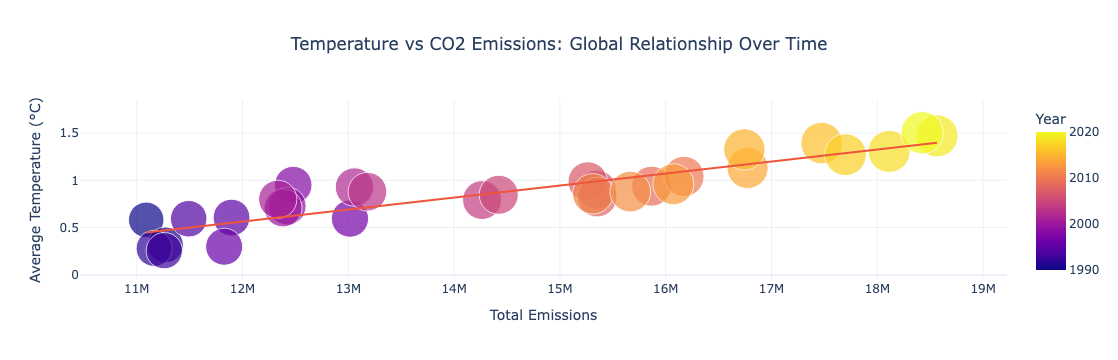

In [21]:
fig = px.scatter(
    correlation,
    x="total_emission",
    y="Average Temperature °C",
    size="pop_tot",
    color="Year",
    title="Temperature vs CO2 Emissions: Global Relationship Over Time",
    template="plotly_white",
    size_max=30,
    trendline="ols",
    hover_data={
        "Year": True,
        "total_emission": ":,.0f",
        "Average Temperature °C": ":.2f",
        "pop_tot": ":,.0f"
    }
)
fig.update_layout(
    xaxis_title="Total Emissions",
    yaxis_title="Average Temperature (°C)",
    title_x=0.5,
    coloraxis_colorbar_title="Year"
)
fig.show()

### Insight: Strengthening Relationship Between Emissions and Temperature Over Time

- A clear positive linear relationship exists between total emissions and average temperature.
- The color gradient shows a temporal progression, with later years clustering toward higher emissions and higher temperatures.
- The linear trendline reinforces that the relationship is structurally consistent, supporting the role of sustained emissions in driving climate change.

### 6D. Correlation Heatmap

In [22]:
import plotly.express as px
import pandas as pd

heatmap_cols = [
    "total_emission", "Average Temperature °C", "pop_tot",
    "Urban population", "Rural population",
    "emission_per_capita", "urban_ratio",
    "emission_change", "temp_change"
]

corr_matrix = df_clean[heatmap_cols].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Correlation Heatmap of Emissions, Temperature, and Population Variables",
)

fig.update_layout(
    width=900,
    height=650,
    title_x=0.5,
    title_font_size=15,
    template="plotly_white",
    coloraxis_colorbar=dict(
        title="Pearson r",
        thickness=15,
        len=0.8,
    ),
)

fig.update_xaxes(tickangle=45, tickfont_size=11)
fig.update_yaxes(tickfont_size=11)
fig.update_traces(textfont_size=10)

fig.show()

###  Insight: Strong Structural Link Between Population and Emissions

- Total emissions show a very strong positive correlation with total population and urban population.
- Emission per capita shows weak or near-zero correlation with total emissions — aggregate emissions are dominated by population size rather than individual intensity.
- Temperature shows only a weak direct correlation with emissions, suggesting that climate response is influenced by cumulative and lagged effects.

### 6E. Distribution — Temperature Box Plots

In [23]:
fig = px.box(
    df_clean,
    x="Year",
    y="Average Temperature °C",
    color="Year",
    color_discrete_sequence=px.colors.sequential.Viridis,
    title='<b>Average temperature distribution by years'
)
fig.show()

# Filter out 'Other' and sample every 3 years
box_df = df_clean[
    (df_clean["continent"] != "Other") &
    (df_clean["Year"] % 3 == 0)
].copy()

yearly_median = box_df.groupby("Year")["Average Temperature °C"].median().reset_index()

fig = px.box(
    box_df,
    x="Year",
    y="Average Temperature °C",
    color="continent",
    points=False,
    title="Average Temperature Distribution by Year and Continent",
    color_discrete_sequence=px.colors.qualitative.Set2,
    category_orders={"continent": sorted(box_df["continent"].unique())},
)

fig.add_scatter(
    x=yearly_median["Year"],
    y=yearly_median["Average Temperature °C"],
    mode="lines",
    name="Global Median Trend",
    line=dict(color="black", width=2.5, dash="dash"),
)

fig.update_layout(
    height=550, width=1100, title_x=0.5, font=dict(size=12),
    xaxis=dict(title="Year", tickmode="linear", dtick=3),
    yaxis=dict(title="Average Temperature (°C)"),
    legend=dict(title="<b>Continent</b>", x=1.02, y=0.5,
                bgcolor="rgba(255,255,255,0.9)", bordercolor="lightgray",
                borderwidth=1, itemsizing="constant", itemwidth=40),
    boxmode="group",
)

###  Insight: Upward Shift in Temperature Distribution Over Time

- The distribution of average temperature shifts upward over time, with median values steadily increasing from the early 1990s to 2020.
- The increasing upper range and more frequent high-value outliers in recent years suggest that extreme temperature events are becoming more common.

### Insight: Regional Variation in Warming Trends Across Continents

- All continents show an upward shift in temperature distributions over time, indicating that warming is a global phenomenon.
- The rate and variability of temperature change differ across regions, with some continents (e.g., Asia and Europe) showing higher medians in later years.
- These patterns highlight the importance of region-specific climate responses.

### 6F. 3D Scatter Plot — Temperature vs CO₂ by Continent

In [24]:
plot_df = df_clean[df_clean["continent"] != "Other"]
plot_df = (
    plot_df.groupby(["continent", "Year"], as_index=False)
    .agg({"total_emission": "sum", "Average Temperature °C": "mean", "pop_tot": "sum"})
    .sort_values(["continent", "Year"])
)

fig = px.scatter_3d(
    plot_df,
    x="Year", y="Average Temperature °C", z="total_emission",
    color="continent", size="pop_tot", size_max=28, opacity=0.8,
    template="plotly_white",
    title="Temperature vs CO₂ Emissions by Continent and Year",
    labels={"Year": "Year", "Average Temperature °C": "Avg Temperature (°C)",
            "total_emission": "Total CO₂ Emissions", "pop_tot": "Population"},
    hover_name="continent",
    hover_data={"Year": True, "Average Temperature °C": ":.2f",
                "total_emission": ":,.0f", "pop_tot": ":,.0f"}
)
fig.update_traces(marker=dict(line=dict(width=0.5, color="darkgray")))
fig.update_layout(
    width=1000, height=650,
    legend=dict(title="Continent", x=1.02, y=0.95),
    margin=dict(l=20, r=20, t=60, b=20),
    scene=dict(
        xaxis=dict(title="Year", backgroundcolor="rgb(245,245,245)", gridcolor="lightgray"),
        yaxis=dict(title="Avg Temperature (°C)", backgroundcolor="rgb(245,245,245)", gridcolor="lightgray"),
        zaxis=dict(title="Total CO₂ Emissions", backgroundcolor="rgb(245,245,245)", gridcolor="lightgray"),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    title=dict(x=0.5, xanchor="center")
)
fig.show()

###  Insight: Multi-Dimensional Relationship Between Time, Emissions, and Temperature

- The 3D distribution reveals a clear upward progression over time, with both emissions and temperature increasing simultaneously across most continents.
- Asia stands out with significantly higher emission levels, while the clustering of points in later years at higher values suggests a cumulative effect.

### 6G. Bar Chart — Top 15 Emitting Countries

In [25]:

# ===== 1. Fix duplicate/invalid country names =====
replace_map = {"China, mainland": "China", "USSR": "Russia"}
df_clean["Area"] = df_clean["Area"].replace(replace_map)

# ===== 2. Recompute country summary =====
country_summary = df_clean.groupby("Area", as_index=False).agg({
    "total_emission": "mean",
    "emission_per_capita": "mean",
    "Average Temperature °C": "mean",
    "pop_tot": "mean",
    "urban_ratio": "mean",
})

# ===== 3. Select top 15 =====
top15 = (
    country_summary.nlargest(15, "total_emission")
    .sort_values("total_emission", ascending=True)
)

# ===== 4. Plot =====
fig = px.bar(
    top15,
    x="total_emission",
    y="Area",
    orientation="h",
    title="Top 15 Countries by Average Agrifood CO₂ Emissions (1990–2020)",
    template="plotly_white",
    text="total_emission"
)

# ===== 5. Layout improvements =====
fig.update_layout(
    height=500,
    xaxis_title="Average Total Emission",
    yaxis_title="Country",
    title_x=0.5,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

# ===== 6. Better labels & hover =====
fig.update_traces(
    texttemplate='%{text:.2s}',
    textposition='outside',
    hovertemplate="<b>%{y}</b><br>Emission: %{x:,.2f}<extra></extra>"
)

fig.show()

### Insight: Concentration of Emissions Among a Few Key Countries

- Emissions are highly concentrated among a small number of countries, with China dominating by a significant margin.
- Brazil, Indonesia, the United States, and India also account for a large share, reflecting their scale of agricultural production and land use.
- Targeted mitigation policies in a small group of high-emitting countries could have a significant global impact.

### 6H. Histogram + KDE — Emission per Capita by Continent

In [26]:
import plotly.figure_factory as ff

# Filter data
plot_epc = df_clean[df_clean["continent"] != "Other"].copy()
cap = plot_epc["emission_per_capita"].quantile(0.99)
plot_epc = plot_epc[plot_epc["emission_per_capita"] <= cap]

# Prepare data for each continent
continent_groups = plot_epc.groupby("continent")["emission_per_capita"].apply(list)

data = list(continent_groups)

group_labels = list(continent_groups.index)  # continent names

# Create density plot
fig = ff.create_distplot(
    data,
    group_labels,
    show_hist=False,  # hide histogram bars
    show_rug=False
)

fig.update_layout(
    title="Distribution of Emission per Capita by Continent (1990–2020)",
    xaxis_title="Emission per Capita",
    yaxis_title="Density",
    template="plotly_white",
    plot_bgcolor="white",
    paper_bgcolor="white",
    title_x=0.5
)

fig.update_xaxes(range=[0, cap])

fig.show()

###  Insight: Large Inequality in Per-Capita Emissions Across Regions

- Most countries across all continents are concentrated at very low emission per capita levels.
- The long right tail in several continents shows that a small number of countries have disproportionately high per-capita emissions.
- Smaller or less populous countries can still have significant individual environmental impact.

### 6I. Dual-Axis Bar + Line Chart — Continental Emissions

In [27]:
# ===== INTERACTIVE CONTINENTAL ANALYSIS =====

import plotly.graph_objects as go
from plotly.subplots import make_subplots

def continental_emission_plotly(year=2020):

    continent_df = df_clean.loc[
        (df_clean["pop_tot"] > 500000) &
        (df_clean["Year"] == year) &
        (df_clean["continent"] != "Other")
    ].groupby("continent").agg({
        "total_emission": "sum",
        "Average Temperature °C": "median",
        "emission_per_capita": "mean"
    }).reset_index()

    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=[
            f"Total CO₂ Emissions by Continent ({year})",
            f"CO₂ Emission per Capita by Continent ({year})"
        ],
        specs=[[{"secondary_y": True}, {"secondary_y": True}]]
    )

    # ===== LEFT: Total Emissions =====
    df1 = continent_df.sort_values("total_emission", ascending=False)

    fig.add_trace(go.Bar(
        x=df1["continent"],
        y=df1["total_emission"],
        name="Total Emission",
        hovertemplate="<b>%{x}</b><br>Emission: %{y:,.2f}<extra></extra>"
    ), row=1, col=1, secondary_y=False)

    fig.add_trace(go.Scatter(
        x=df1["continent"],
        y=df1["Average Temperature °C"],
        mode='lines+markers',
        name="Avg Temp (°C)",
        hovertemplate="Temp: %{y:.2f}°C<extra></extra>"
    ), row=1, col=1, secondary_y=True)

    # ===== RIGHT: Per Capita =====
    df2 = continent_df.sort_values("emission_per_capita", ascending=False)

    fig.add_trace(go.Bar(
        x=df2["continent"],
        y=df2["emission_per_capita"],
        name="Emission per Capita",
        hovertemplate="<b>%{x}</b><br>Per Capita: %{y:.4f}<extra></extra>"
    ), row=1, col=2, secondary_y=False)

    fig.add_trace(go.Scatter(
        x=df2["continent"],
        y=df2["Average Temperature °C"],
        mode='lines+markers',
        name="Avg Temp (°C)",
        showlegend=False,
        hovertemplate="Temp: %{y:.2f}°C<extra></extra>"
    ), row=1, col=2, secondary_y=True)

    # ===== Layout =====
    fig.update_layout(
        title=f"Continental Agrifood CO₂ Emissions — {year}",
        template="plotly_white",
        height=600,
        title_x=0.5
    )

    fig.update_xaxes(tickangle=45)

    fig.show()


In [28]:
# Run function
continental_emission_plotly(2020)

###  Insight: Asia as the Dominant Contributor and Reversal of Rankings Per Capita

- Asia contributes the largest share of total agrifood CO₂ emissions by a wide margin.
- When normalized per capita, the ranking changes significantly — regions like Oceania and South America show higher per-capita values.
- The combination of total and per-capita views provides a more balanced understanding of both scale and intensity of emissions.

### 6J. Pairplot — Scatter Matrix of Key Emission Sources

In [29]:
pair_vars = [
    "Savanna fires", "total_emission", "Rice Cultivation",
    "Food Transport", "Average Temperature °C"
]

pair_df = df_clean[df_clean["continent"] != "Other"][pair_vars + ["continent"]].dropna()
for col in pair_vars:
    cap = pair_df[col].quantile(0.99)
    pair_df[col] = pair_df[col].clip(upper=cap)

fig = px.scatter_matrix(
    pair_df,
    dimensions=pair_vars,
    color="continent",
    opacity=0.6,
    title="Emission Sources vs Temperature by Continent",
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={col: col.replace(" ", "<br>") for col in pair_vars},
)
fig.update_traces(marker=dict(size=5), diagonal_visible=False, showupperhalf=False)
fig.update_layout(
    height=800, width=950, title_x=0.5, font=dict(size=12),
    legend=dict(title="<b>Continent</b>", x=1.02, y=0.5,
                bgcolor="rgba(255,255,255,0.9)", bordercolor="lightgray",
                borderwidth=1, font=dict(size=11), itemsizing="constant", itemwidth=40),
)
fig.show()

## Preprocessing data for model evaluation
In this stage of the study, we are preprocessing the data to later understand the relationship between various variables related to CO2 emissions in the agri-food sector and the increase in temperatures, which will be our target

## Replacing missing values with regression tecniques:
Let's replace missing values with RandomForest prediction
Let's encode categorical numbers
Let's plot mutual information


In [30]:
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor

In [31]:
df.isna().sum()

Area                                  0
Year                                  0
Savanna fires                        31
Forest fires                         93
Crop Residues                      1389
Rice Cultivation                      0
Drained organic soils (CO2)           0
Pesticides Manufacturing              0
Food Transport                        0
Forestland                          493
Net Forest conversion               493
Food Household Consumption          473
Food Retail                           0
On-farm Electricity Use               0
Food Packaging                        0
Agrifood Systems Waste Disposal       0
Food Processing                       0
Fertilizers Manufacturing             0
IPPU                                743
Manure applied to Soils             928
Manure left on Pasture                0
Manure Management                   928
Fires in organic soils                0
Fires in humid tropical forests     155
On-farm energy use                  956


In [32]:
def regressor_imputer(df, feature, max_depth = 6):
    """ This function replace missing values with
        RanfomForestRegressor forecasting """

    df_filled = df.copy()

    if df_filled[feature].isna().any():
        missing_data = df_filled[df_filled[feature].isna()]
        non_missing_data = df_filled.dropna(subset=[feature])

        X_train = non_missing_data.drop(columns=[feature])
        y_train = non_missing_data[feature]

        imputer = SimpleImputer()
        X_train_imputed = imputer.fit_transform(X_train)
        X_missing = missing_data.drop(columns=[feature])
        X_missing_imputed = imputer.transform(X_missing)

        rf = RandomForestRegressor(max_depth = max_depth)
        rf.fit(X_train_imputed, y_train)

        y_missing_pred = rf.predict(X_missing_imputed)

        df_filled.loc[df_filled[feature].isna(), feature] = y_missing_pred

    return df_filled

In [33]:
num_features = [col for col in df.columns if df[col].dtypes in ["int64", "float64"]]
cat_features = [col for col in df.columns if df[col].dtypes in ["object"]]
# let's create a list with onli missing values feature and the replace them with regression 
missing_values = df[num_features].isna().sum()
missing_list=missing_values[missing_values > 0].keys().tolist()

In [34]:
from tqdm import tqdm
numeric_only = df[num_features ]
def replace_missing(df, missing_list):
    numeric_df = df.copy()
    for feature in tqdm(missing_list):
        numeric_df = regressor_imputer(numeric_df, feature)
    return numeric_df

num_df = replace_missing(numeric_only, missing_list)

100%|███████████████████████████████████████████| 11/11 [00:37<00:00,  3.39s/it]


In [35]:
from sklearn.preprocessing import LabelEncoder

cat_df = df[cat_features].copy() 
label_encoder = LabelEncoder()
for column in cat_df.columns:
    cat_df.loc[:, column] = label_encoder.fit_transform(cat_df[column])

## Model Evaluation:
For demonstrative purposes, in this last phase of the study, we execute a regression model to showcase how temperatures
fluctuate in response to changes in emissions, plotting the feature importance for the best regressor.

In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso, Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [37]:
final_df = pd.concat([cat_df,num_df], axis =1)

def df_split(final_df, year = 2016):
    final_df =final_df.copy()
    x_train = final_df.loc[final_df.Year < year]
    y_train = x_train["Average Temperature °C"]
    x_train = x_train.drop(columns ="Average Temperature °C")    

    x_test =final_df.loc[final_df.Year >= year]
    y_test =x_test["Average Temperature °C"]
    x_test = x_test.drop(columns ="Average Temperature °C")        
    return x_train,y_train,x_test,y_test

In [38]:
x_train,y_train,x_test,y_test = df_split(final_df)

In [39]:

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

def model_evaluation(x_train, x_test, y_train, y_test):

    # ── Safety checks before training ──────────────────────────────────
    # Drop any remaining object/category columns
    x_train = x_train.select_dtypes(include=[np.number])
    x_test  = x_test.select_dtypes(include=[np.number])

    # Align columns (in case drop removed different cols from each split)
    shared_cols = x_train.columns.intersection(x_test.columns)
    x_train = x_train[shared_cols]
    x_test  = x_test[shared_cols]

    # Fill any residual NaN/inf values
    x_train = x_train.replace([np.inf, -np.inf], np.nan).fillna(x_train.median())
    x_test  = x_test.replace([np.inf, -np.inf], np.nan).fillna(x_test.median())

    # Flatten target in case it's a DataFrame
    y_train = np.array(y_train).ravel()
    y_test  = np.array(y_test).ravel()

    print(f"x_train shape: {x_train.shape} | x_test shape: {x_test.shape}")
    print(f"y_train shape: {y_train.shape} | y_test shape: {y_test.shape}")
    print("="*36)

    # ── Models ─────────────────────────────────────────────────────────
    models = {
        "LGBMRegressor":            LGBMRegressor(verbose=-1),
        "KNeighborsRegressor":      KNeighborsRegressor(),
        "RandomForestRegressor":    RandomForestRegressor(),
        "GradientBoostingRegressor":GradientBoostingRegressor(),
        "BaggingRegressor":         BaggingRegressor(),
        "XGBRegressor":             XGBRegressor(verbosity=0)
    }

    # ── Evaluation loop ─────────────────────────────────────────────────
    results = []

    for model_name, model in models.items():
        try:
            model.fit(x_train, y_train)
            test_pred = model.predict(x_test)

            mae = mean_absolute_error(y_test, test_pred)
            mse = mean_squared_error(y_test, test_pred)
            rmse = np.sqrt(mse)

            folds    = KFold(n_splits=5, shuffle=True, random_state=42)
            cv_score = cross_val_score(model, x_train, y_train,
                                       cv=folds,
                                       scoring="neg_mean_absolute_error")
            cv_mae = np.mean(np.abs(cv_score))

            print(f"Model       : {model_name}")
            print(f"MAE         : {round(mae,  4)}")
            print(f"MSE         : {round(mse,  4)}")
            print(f"RMSE        : {round(rmse, 4)}")
            print(f"CV MAE (5-fold): {round(cv_mae, 4)}")
            print("-" * 36)

            results.append({
                "Model": model_name,
                "MAE":   round(mae,    4),
                "MSE":   round(mse,    4),
                "RMSE":  round(rmse,   4),
                "CV_MAE":round(cv_mae, 4)
            })

        except Exception as e:
            print(f"[ERROR] {model_name} failed: {e}")
            print("-" * 36)

    # ── Summary table ───────────────────────────────────────────────────
    results_df = pd.DataFrame(results).sort_values("MAE")
    print("\n📊 Model Comparison Summary (sorted by MAE):")
    print(results_df.to_string(index=False))

    return results_df

results_df = model_evaluation(x_train, x_test, y_train, y_test)

x_train shape: (5830, 29) | x_test shape: (1135, 29)
y_train shape: (5830,) | y_test shape: (1135,)
Model       : LGBMRegressor
MAE         : 0.283
MSE         : 0.142
RMSE        : 0.3768
CV MAE (5-fold): 0.2557
------------------------------------
Model       : KNeighborsRegressor
MAE         : 0.4827
MSE         : 0.357
RMSE        : 0.5975
CV MAE (5-fold): 0.3279
------------------------------------
Model       : RandomForestRegressor
MAE         : 0.2873
MSE         : 0.1471
RMSE        : 0.3836
CV MAE (5-fold): 0.2661
------------------------------------
Model       : GradientBoostingRegressor
MAE         : 0.2966
MSE         : 0.1574
RMSE        : 0.3968
CV MAE (5-fold): 0.2869
------------------------------------
Model       : BaggingRegressor
MAE         : 0.2969
MSE         : 0.1523
RMSE        : 0.3902
CV MAE (5-fold): 0.2784
------------------------------------
Model       : XGBRegressor
MAE         : 0.3007
MSE         : 0.1586
RMSE        : 0.3982
CV MAE (5-fold): 0.2589


## 7. Advanced Visualizations

### 7A. Choropleth Map — Average Total Emission by Country

###  Insight: Different Emission Sources Contribute Unevenly

- The scatter matrix reveals that emission sources such as rice cultivation and food transport vary significantly in their contribution to total emissions.
- Regional clustering indicates that some continents rely more heavily on specific emission sources, reflecting differences in agricultural practices.

In [40]:
choropleth_map = {
    "China, mainland": "China", "USSR": "Russia",
    "United States of America": "United States",
    "Democratic Republic of the Congo": "Congo, Dem. Rep.",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Iran (Islamic Republic of)": "Iran",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "United Republic of Tanzania": "Tanzania",
}

df_choropleth = df_clean.copy()
df_choropleth["Area"] = df_choropleth["Area"].replace(choropleth_map)

country_avg = df_choropleth.groupby("Area", as_index=False).agg({
    "total_emission": "mean",
    "emission_per_capita": "mean",
    "Average Temperature °C": "mean",
    "continent": "first",
})

In [41]:
fig = px.choropleth(
    country_avg,
    locations="Area", locationmode="country names",
    color="total_emission", hover_name="Area",
    hover_data={"total_emission": ":,.0f", "emission_per_capita": ":.4f",
                "Average Temperature °C": ":.2f", "continent": True},
    color_continuous_scale="YlOrRd",
    title="Average Agrifood CO₂ Emissions by Country (1990–2020)",
    labels={"total_emission": "Avg Total Emission"},
)
fig.update_layout(
    height=550, title_x=0.5,
    coloraxis_colorbar=dict(title="Avg Emission", thickness=15, len=0.6),
    geo=dict(showframe=False, showcoastlines=True, coastlinecolor="lightgray",
             projection_type="natural earth")
)
fig.show()

/var/folders/5l/b9_l_n151c7bd4csbdf0sgbh0000gn/T/ipykernel_27022/3217658268.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [42]:
# Choropleth – emission per capita (capped at 75th percentile)
cap_pc = country_avg["emission_per_capita"].quantile(0.75)
country_avg_capped = country_avg.copy()
country_avg_capped["emission_per_capita"] = country_avg_capped["emission_per_capita"].clip(upper=cap_pc)

fig2 = px.choropleth(
    country_avg_capped,
    locations="Area", locationmode="country names",
    color="emission_per_capita", hover_name="Area",
    hover_data={"total_emission": ":,.0f", "emission_per_capita": ":.4f",
                "Average Temperature °C": ":.2f", "continent": True},
    color_continuous_scale="YlGnBu",
    range_color=[country_avg_capped["emission_per_capita"].quantile(0.05), cap_pc],
    title="Average Agrifood CO₂ Emission per Capita by Country (1990–2020)",
    labels={"emission_per_capita": "Emission per Capita (kt)"},
)
fig2.update_layout(
    height=550, title_x=0.5,
    coloraxis_colorbar=dict(title="Emission<br>per Capita (kt)", thickness=15, len=0.6, tickformat=".3f"),
    geo=dict(showframe=False, showcoastlines=True, coastlinecolor="lightgray",
             showocean=True, oceancolor="aliceblue", showlakes=True, lakecolor="aliceblue",
             projection_type="natural earth"),
    annotations=[dict(x=0.5, y=-0.05, xref="paper", yref="paper",
                      text="Note: values capped at 75th percentile to improve colour contrast",
                      showarrow=False, font=dict(size=10, color="gray"))]
)
fig2.show()

/var/folders/5l/b9_l_n151c7bd4csbdf0sgbh0000gn/T/ipykernel_27022/687202405.py:6: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



###  Insight: Geographic Concentration and Hidden Per-Capita Inequality

- Total agrifood emissions are heavily concentrated in a few large economies (China, India, Brazil, USA).
- The per-capita map reveals significant inequality — many smaller or less populous countries display higher per-capita values.
- Environmental impact cannot be fully understood using total emissions alone.

### 7B. Animated Choropleth — Emissions Over Time

In [43]:
df_anim = df_choropleth[df_choropleth["continent"] != "Other"].copy()

fig3 = px.choropleth(
    df_anim,
    locations="Area", locationmode="country names",
    color="total_emission", hover_name="Area",
    animation_frame="Year",
    hover_data={"total_emission": ":,.0f", "emission_per_capita": ":.4f",
                "Average Temperature °C": ":.2f", "continent": True},
    color_continuous_scale="YlOrRd",
    range_color=[0, df_anim["total_emission"].quantile(0.95)],
    title="Agrifood CO₂ Emissions by Country Over Time (1990–2020)",
    labels={"total_emission": "Total Emission"},
)
fig3.update_layout(
    height=550, title_x=0.5,
    coloraxis_colorbar=dict(title="Total Emission", thickness=15, len=0.6),
    geo=dict(showframe=False, showcoastlines=True, coastlinecolor="lightgray",
             showocean=True, oceancolor="aliceblue", projection_type="natural earth")
)
fig3.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 600
fig3.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 300
fig3.show()

/var/folders/5l/b9_l_n151c7bd4csbdf0sgbh0000gn/T/ipykernel_27022/4198264759.py:3: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### 7C. Animated Bubble Chart — Emission vs Temperature by Continent

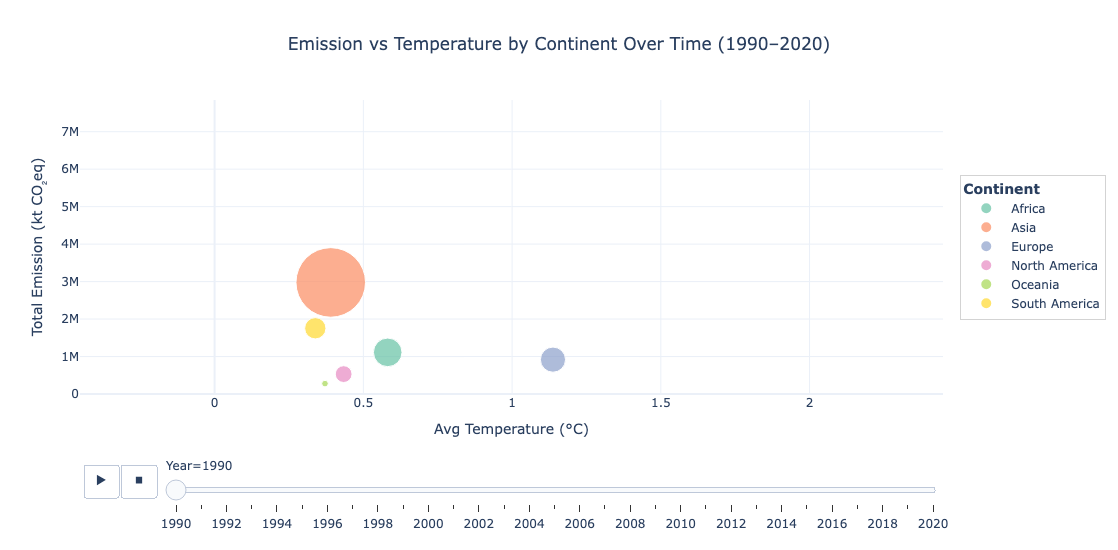

In [44]:
cont_anim = df_clean[df_clean["continent"] != "Other"].groupby(
    ["continent", "Year"], as_index=False
).agg({
    "total_emission": "sum",
    "Average Temperature °C": "mean",
    "emission_per_capita": "mean",
    "pop_tot": "sum",
})

fig4 = px.scatter(
    cont_anim,
    x="Average Temperature °C", y="total_emission",
    size="pop_tot", color="continent",
    animation_frame="Year", animation_group="continent",
    hover_name="continent",
    hover_data={"total_emission": ":,.0f", "Average Temperature °C": ":.2f",
                "emission_per_capita": ":.4f", "pop_tot": ":,.0f"},
    size_max=60,
    range_x=[cont_anim["Average Temperature °C"].min() - 0.2,
             cont_anim["Average Temperature °C"].max() + 0.2],
    range_y=[0, cont_anim["total_emission"].max() * 1.1],
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Emission vs Temperature by Continent Over Time (1990–2020)",
    labels={"total_emission": "Total Emission (kt CO₂eq)",
            "Average Temperature °C": "Avg Temperature (°C)", "pop_tot": "Population"},
    template="plotly_white",
)
fig4.update_layout(
    height=550, title_x=0.5, font=dict(size=12),
    legend=dict(title="<b>Continent</b>", x=1.02, y=0.5,
                bgcolor="rgba(255,255,255,0.9)", bordercolor="lightgray",
                borderwidth=1, itemsizing="constant", itemwidth=40),
)
fig4.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 700
fig4.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 300
fig4.show()

###  Insight: Expanding Emissions and Diverging Regional Paths

- The animations show a clear expansion of high-emission regions over time, with more countries transitioning into higher emission categories.
- Asia consistently moves toward higher emission levels; other continents show more moderate increases.
- While climate change is global, its drivers and progression differ significantly across regions.

### 7D. Sankey Diagram — Emission Flow: Continent → Source → Temperature Zone

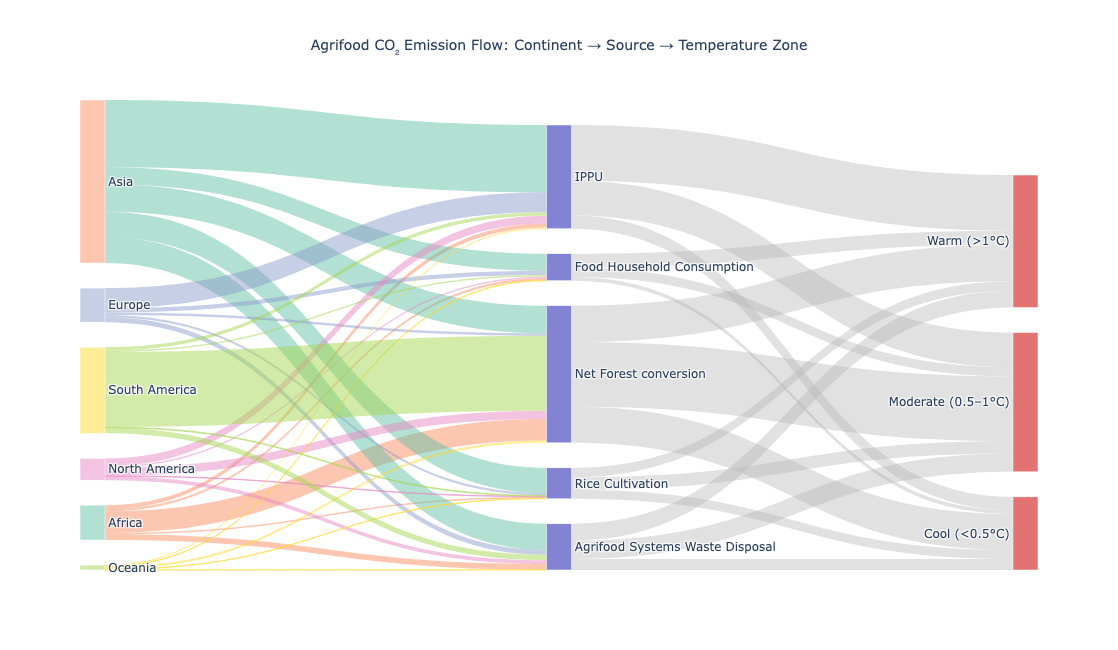

In [45]:
# Top 5 emission sources
top5_sources = (
    long_df.groupby("emission_source")["emission_value"]
    .sum()
    .nlargest(5)
    .index.tolist()
)

def temp_zone(temp):
    if temp < 0.5:
        return "Cool (<0.5°C)"
    elif temp < 1.0:
        return "Moderate (0.5–1°C)"
    else:
        return "Warm (>1°C)"

sankey_df = long_df[
    (long_df["emission_source"].isin(top5_sources)) &
    (long_df["continent"] != "Other")
].copy()
sankey_df["temp_zone"] = sankey_df["Average Temperature °C"].apply(temp_zone)

sankey_agg = sankey_df.groupby(
    ["continent", "emission_source", "temp_zone"], as_index=False
)["emission_value"].sum()

continents  = sankey_agg["continent"].unique().tolist()
sources     = sankey_agg["emission_source"].unique().tolist()
temp_zones  = sankey_agg["temp_zone"].unique().tolist()
all_nodes   = continents + sources + temp_zones
node_idx    = {name: i for i, name in enumerate(all_nodes)}

links_source, links_target, links_value, links_color = [], [], [], []

continent_colors = {
    "Asia":          "rgba(102,194,165,0.5)",
    "Africa":        "rgba(252,141,98,0.5)",
    "Europe":        "rgba(141,160,203,0.5)",
    "North America": "rgba(231,138,195,0.5)",
    "South America": "rgba(166,216,84,0.5)",
    "Oceania":       "rgba(255,217,47,0.5)",
}

# Layer 1: continent → source
layer1 = sankey_agg.groupby(["continent", "emission_source"], as_index=False)["emission_value"].sum()
for _, row in layer1.iterrows():
    links_source.append(node_idx[row["continent"]])
    links_target.append(node_idx[row["emission_source"]])
    links_value.append(row["emission_value"])
    links_color.append(continent_colors.get(row["continent"], "rgba(150,150,150,0.4)"))

# Layer 2: source → temp zone
layer2 = sankey_agg.groupby(["emission_source", "temp_zone"], as_index=False)["emission_value"].sum()
for _, row in layer2.iterrows():
    links_source.append(node_idx[row["emission_source"]])
    links_target.append(node_idx[row["temp_zone"]])
    links_value.append(row["emission_value"])
    links_color.append("rgba(180,180,180,0.4)")

node_colors = (
    list(continent_colors.values()) +
    ["rgba(100,100,200,0.8)"] * len(sources) +
    ["rgba(220,80,80,0.8)"] * len(temp_zones)
)

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(pad=25, thickness=25,
              line=dict(color="white", width=0.5),
              label=all_nodes, color=node_colors),
    link=dict(source=links_source, target=links_target,
              value=links_value, color=links_color),
))
fig.update_layout(
    title=dict(text="Agrifood CO₂ Emission Flow: Continent → Source → Temperature Zone",
               x=0.5, font=dict(size=14)),
    height=650, font=dict(size=12),
    paper_bgcolor="white", plot_bgcolor="white",
)
fig.show()

###  Insight: Complex Flow of Emissions Across Sources and Climate Zones

- The Sankey diagram reveals that emissions flow through multiple pathways, with key sources such as net forest conversion and IPPU contributing significantly.
- Asia dominates many of the major flows.
- The diversity of pathways highlights that effective mitigation requires addressing multiple emission sources simultaneously.

### 7E. Uncertainty Visualization — 95% Confidence Intervals by Continent

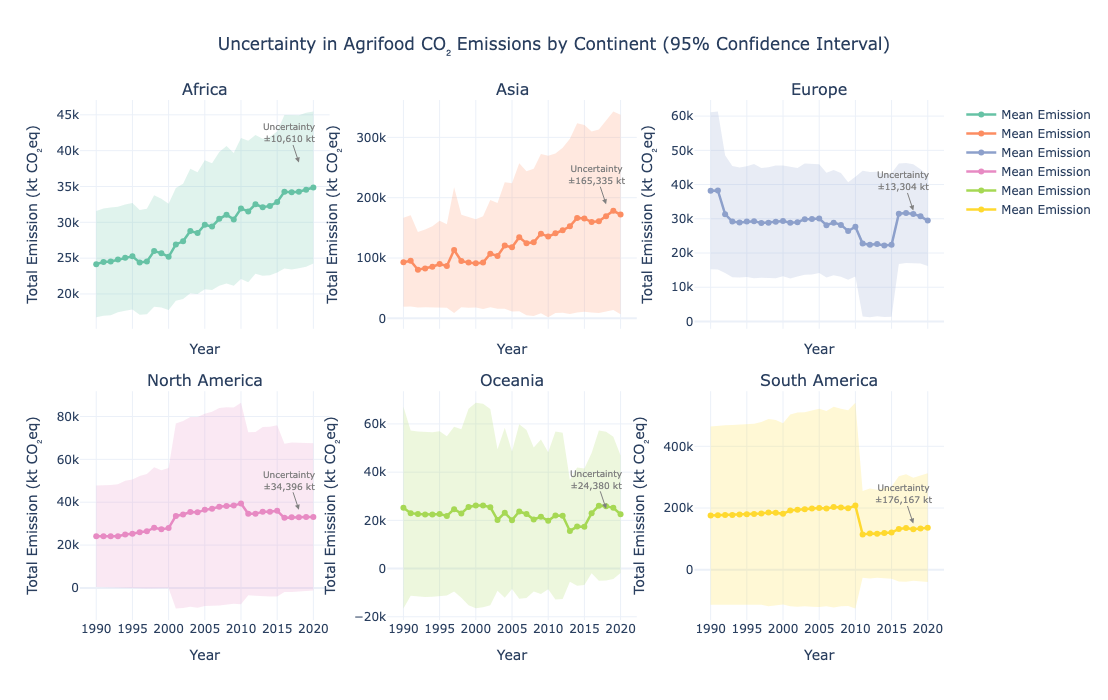

In [46]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

# ===== 1. Compute mean and 95% CI per continent per year =====
records = []
for (continent, year), group in df_clean[df_clean["continent"] != "Other"].groupby(["continent", "Year"]):
    x = group["total_emission"].dropna()
    n = len(x)
    mean = x.mean()
    if n >= 2:
        se = stats.sem(x)
        ci = se * stats.t.ppf(0.975, df=n - 1)
    else:
        ci = 0
    records.append({
        "continent": continent,
        "Year": year,
        "mean": mean,
        "ci_low": mean - ci,
        "ci_high": mean + ci
    })

uncert_df = pd.DataFrame(records)
continents_list = sorted(uncert_df["continent"].unique())

# ===== 2. Create subplot grid =====
rows = 2
cols = 3
fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=continents_list,
    shared_xaxes=True,
    vertical_spacing=0.12
)

# Assign colors
colors = px.colors.qualitative.Set2

# ===== 3. Add traces for each continent =====
for i, continent in enumerate(continents_list):
    cont = uncert_df[uncert_df["continent"] == continent].sort_values("Year")
    row = i // cols + 1
    col = i % cols + 1
    color = colors[i % len(colors)]

    # CI shading
    fig.add_trace(go.Scatter(
        x=list(cont["Year"]) + list(cont["Year"][::-1]),
        y=list(cont["ci_high"]) + list(cont["ci_low"][::-1]),
        fill='toself',
        fillcolor=color.replace(')', ',0.2)').replace('rgb', 'rgba'),
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo='skip',
        showlegend=False,
    ), row=row, col=col)

    # Mean line
    fig.add_trace(go.Scatter(
        x=cont["Year"],
        y=cont["mean"],
        mode='lines+markers',
        line=dict(color=color, width=2.5),
        name='Mean Emission',
        hovertemplate="<b>%{x}</b><br>Mean: %{y:,.0f} kt<extra></extra>"
    ), row=row, col=col)

    # Annotate last point
    last = cont.iloc[-1]
    uncertainty_width = last["ci_high"] - last["ci_low"]
    fig.add_annotation(
        x=last["Year"] - 2,
        y=last["mean"] * 1.1,
        text=f"Uncertainty<br>±{uncertainty_width/2:,.0f} kt",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowcolor="gray",
        font=dict(size=9, color="gray"),
        row=row, col=col
    )

# ===== 4. Layout =====
fig.update_layout(
    height=700,
    width=1200,
    title_text="Uncertainty in Agrifood CO₂ Emissions by Continent (95% Confidence Interval)",
    title_x=0.5,
    template="plotly_white",
    hovermode="x unified"
)

# Shared x-axis labels
for i in range(rows * cols):
    fig.update_xaxes(title_text="Year", row=(i // cols) + 1, col=(i % cols) + 1, dtick=5)
    fig.update_yaxes(title_text="Total Emission (kt CO₂eq)", row=(i // cols) + 1, col=(i % cols) + 1)

fig.show()

### Insight: Increasing Emissions with Significant Uncertainty Across Regions

- All continents show an overall increase in mean emissions over time, confirming a consistent upward trend globally.
- Asia and South America exhibit particularly large uncertainty ranges, suggesting more variability in emission patterns.
- Europe shows comparatively stable trends, indicating more consistent emission behavior.

## Final Conclusion

- **Agrifood emissions** are strongly driven by population growth, urbanization, and regional production intensity.
- **Emission concentration**: a small number of countries are responsible for the majority of global agrifood emissions, while per-capita analysis reveals hidden inequalities.
- **Temperature trends** reflect cumulative environmental impact rather than short-term changes.
- The relationship between emissions and climate is **complex**, involving multiple interacting sources and regional differences.
- Overall, climate change is a **long-term, structural process** requiring coordinated global and region-specific strategies.